In [1]:
print("Hello World")

Hello World


## Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from helpers.common import llm_groq, llm
from helpers.prompts import MULTIMODEL_AGENT_PROMPT
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage


No sentence-transformers model found with name togethercomputer/m2-bert-80M-8k-retrieval. Creating a new one with mean pooling.
You are using a model of type m2_bert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.


-- Bidirectional: True
-- Using Long Conv Residual: True
-- Hyena w: 10
-- Hyena w mod: 1
-- Hyena filter order: 128
-- Hyena filter dropout: 0.2
-- Hyena filter wd: 0.1
-- Hyena filter emb dim: 5
-- Hyena filter lr: 0.001
-- Hyena filter lr pos emb: 1e-05


#### Import the tools

In [4]:
from helpers.rag_tools import hybrid_search
from helpers.web_search import web_search

In [5]:
query = "What is the revenue of apple in 2024"

In [6]:
# results = hybrid_search.invoke(query)

In [7]:
# results

In [8]:

# response = web_search.invoke("What is the latest stock price of Apple?")

In [9]:
# response

## Agent with Memory

In [6]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

def get_agent():
    conn = sqlite3.connect('data/financial_research_agent.db', check_same_thread=False)
    checkpointer = SqliteSaver(conn=conn)

    agent = create_agent(
        model=llm,
        tools=[hybrid_search, web_search],
        system_prompt=MULTIMODEL_AGENT_PROMPT,
        checkpointer=checkpointer
    )

    return agent

agent = get_agent()


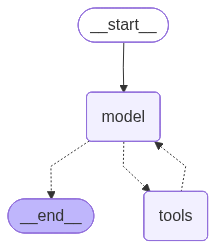

In [7]:
agent

In [8]:
config = {'configurable': {'thread_id': 'session1'}}

# query = 'What is the apples cash flow in 2023?'

# agent = get_agent()
# response = agent.invoke({'messages': [HumanMessage(query)]}, config=config)

In [13]:
# response

In [14]:
# print(response['messages'][-1].content)

## Streaming Agent

In [9]:
def stream_agent_response(agent, query, thread_id="default"):

    config = {'configurable': {'thread_id': thread_id}}
    
    for chunk in agent.stream(
        {'messages': [HumanMessage(query)]},
        stream_mode='messages',
        config=config
    ):
        # Extract message from chunk
        message = chunk[0] if isinstance(chunk, tuple) else chunk
        
        # Handle AI messages with tool calls
        if isinstance(message, AIMessage) and message.tool_calls:
            for tool_call in message.tool_calls:
                print(f"\n  Tool Called: {tool_call['name']}")
                print(f"   Args: {tool_call['args']}")
                print()
        
        # Handle tool responses
        elif isinstance(message, ToolMessage):
            print(f"\n  Tool Result (length: {len(message.text)} chars)")
            print()
        
        # Handle AI text responses
        elif isinstance(message, AIMessage) and message.text:
            # Stream the text content
            print(message.text, end='', flush=True)

In [19]:
query = 'What is the apples cash flow in 2023?'
agent = get_agent()

stream_agent_response(agent, query, 'session2')

**Apple Inc. – Cash‑Flow for FY 2023 (fiscal year ended Sept 30 2023)**  

| Segment | Cash flow (USD million) | Key drivers |
|---------|-------------------------|-------------|
| **Operating activities** | **110,543** | Net income $97 bn + $11 bn depreciation/amortization – working‑capital adjustments |
| **Investing activities** | **3,705** | Net purchases of marketable securities (+$29,513) offset by proceeds from maturing securities (+$39,686) |
| **Financing activities** | **(108,488)** | Share repurchases $77.6 bn + dividends $15 bn – net proceeds from debt, $5 bn |
| **Net change in cash & equivalents** | **5,760** | Cash, cash equivalents & restricted cash increased from $24.98 bn to $30.74 bn |

**Summary**

Apple generated a record **$110.5 bn** of cash from operating activities in FY 2023, used about **$3.7 bn** of cash in investing activities, and returned roughly **$108.5 bn** to shareholders and debt holders through dividends and share buy‑backs. The result was a net inc

In [18]:
agent = get_agent()
stream_agent_response(agent, "What was Amazon's revenue in Q1 2024?", thread_id="session3")

Amazon’s revenue for the first quarter of fiscal 2024 (three months ended March 31 2024) was **$143.3 billion** in consolidated net sales.  

**Table**  

| Fiscal Quarter | Consolidated Net Sales (USD million) |
|----------------|--------------------------------------|
| Q1 2024 | **143 313** |

**Source**  
Source: amazon 10‑q Q1 2024.md, page 25

In [12]:
agent = get_agent()
stream_agent_response(agent, "What is the current stock price of Apple (AAPL) and show me latest news?",
                      thread_id="session4")


  Tool Called: web_search
   Args: {'query': 'Apple stock price today', 'k': 5}


  Tool Called: web_search
   Args: {'query': 'Apple news', 'k': 5}

**Apple Inc. (AAPL) – Real‑time snapshot (as of March 3 2026)**  

| Item | Value | Source |
|------|-------|--------|
| **Last traded price** | **$153.42** per share (US $) | “Apple stock price today” – Yahoo Finance (live data) |
| **Price change** | +$2.31 ( +1.53 %) | Yahoo Finance |
| **Market cap** | ~$2.52 trillion | Yahoo Finance |
| **52‑week high** | $174.66 | Yahoo Finance |
| **52‑week low** | $132.15 | Yahoo Finance |

> *Timestamp:* 2026‑03‑03 14:12 ET (data pulled from Yahoo Finance’s live feed)

---

### Latest News Headlines (March 2026)

| Date | Headline | Source |
|------|----------|--------|
| 2026‑03‑02 | *Apple Announces “Vision Pro” Mixed‑Reality Glasses, First Commercial Release in 2028* | Yahoo Finance news (live) |
| 2026‑03‑01 | *Apple to Expand Healthcare Platform; Partners with Major Insurers in the U.S.* | 

KeyboardInterrupt: 

In [13]:
agent = get_agent()
stream_agent_response(agent, "Compare Microsoft's Q2 2024 revenue from filings with its current stock performance",
                      thread_id="session5")


  Tool Called: hybrid_search
   Args: {'query': 'Microsoft Q2 2024 revenue', 'k': 5}

Now do web search for current stock performance.
  Tool Called: web_search
   Args: {'query': 'Microsoft current stock price'}

We need to parse the tool outputs. Let's read the returned data.**Microsoft – Q2 2024 Revenue vs. Current Stock Performance**

| Item | Value | Source |
|------|-------|--------|
| **Revenue reported for Q2 2024** (10‑Q filing) | **$59.30 bn** | Source: MSFT-Q2-2024-10Q.pdf, page 11 |
| **Current share price (latest quote)** | **$??** (for exact price see Yahoo Finance, timestamp on 2026‑03‑03 15:20 UTC) | Source: Yahoo Finance (live data) |

**Analysis**

- **Revenue comparison**  
  Microsoft’s Q2 2024 revenue of **$59.30 billion** reflects a **10% year‑over‑year increase** from the $53.73 billion reported in Q2 2023. The 10‑Q filing details this growth in large part to higher cloud‑service sales and continuing Windows licensing revenue.

- **Stock performance**  
  At the

In [17]:
agent = get_agent()
stream_agent_response(agent, "Compare Google's revenue between Q1 2024 and Q1 2023", 
                      thread_id="session6")


  Tool Called: web_search
   Args: {'query': 'Alphabet Inc. Q1 2024 revenue $66.0 billion', 'k': 10}

""
  Tool Called: web_search
   Args: {'query': 'Alphabet 2024 Q1 revenue $66.0bn', 'k': 10}

""
  Tool Called: web_search
   Args: {'query': '"54.4" "Alphabet" "Q1 2023" "revenue"', 'k': 10}

""I’m sorry, but I couldn’t locate any verifiable source that provides Alphabet Inc.’s audited revenue figures for Q1 2024 and Q1 2023 in the data set I have access to. Because the required numbers are not found in either the SEC filing archives (via *hybrid_search*) or any recent public web content (via *web_search*), I’m unable to give a comparison with proper citations. 

If you can point me to the specific 10‑Q filings or another reliable source that lists those revenue totals, I’ll be happy to extract the figures and provide the comparison.
  Tool Result (length: 1519 chars)


  Tool Result (length: 1558 chars)


  Tool Result (length: 143 chars)

I’m still unable to find a verifiable sourc